In [9]:
from pylib.preamble import *
enable_autoreload()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# *Fetch* and *assess* data form eurostat

## 1. `Fetch`

### 1. Rise of electrification

As per: https://ec.europa.eu/eurostat/databrowser/view/nrg_ind_re/default/table?lang=en

In [10]:
# aggregate
df_a = fetch(nrg_bal=var_groups.total)

# main categories
df_m = fetch(nrg_bal=var_groups.parent)

# subs
df_s = fetch(nrg_bal=var_groups.subs)

### 2. Energiforbrug pr. sektor (vægte til dekomponering)

As per: https://ec.europa.eu/eurostat/databrowser/view/nrg_bal_c__custom_21125787/default/table

In [11]:
_excl = {'FC_OTH_NSP_E', 'FC_TRA_NSP_E', 'FC_TRA_DAVI_E', 'FC_TRA_DNAVI_E'}
subs_enw = [s for s in var_groups.subs if s not in _excl]

countries = [g for g in var_groups.countries if g not in {'UK', 'ES'}]

df_enw = fetch_energy_weights(sectors=subs_enw, countries=countries)

### 3. construct dataset

In [12]:
# Electricity share per sector
elec_share = (
    df_s[df_s.geo.isin(countries)]
    [['geo', 'year', 'nrg_bal', 'label', 'value']]
    .rename(columns={'value': 'elec_share_pct'})
)

# Energy consumption per sector
enw = (
    df_enw[['geo', 'year', 'nrg_bal', 'value']]
    .rename(columns={'value': 'energy_tj'})
)

df = elec_share.merge(enw, on=['geo', 'year', 'nrg_bal'], how='left')

In [13]:
DROP_SECTORS = list(_excl)
df = df[~df['nrg_bal'].isin(DROP_SECTORS)].reset_index(drop=True)

In [14]:
out = Path("0_intermediate")
out.mkdir(exist_ok=True)

df.to_parquet(out / "df.parquet",       index=False)  # main: elec share + energy weights
df_a.to_parquet(out / "df_a.parquet",   index=False)  # aggregate electrification
df_m.to_parquet(out / "df_m.parquet",   index=False)  # parent categories
df_s.to_parquet(out / "df_s.parquet",   index=False)  # subsectors (pre-exclusion)
df_enw.to_parquet(out / "df_enw.parquet", index=False) # energy weights (TJ)

print("Saved to", out.resolve())

Saved to C:\Users\LinusLindquist\e-tank\E-Tank - Data\PROJEKTER\02 GRØN OMSTILLING\Den grønne energigruppe\elektrificering_eurostat\0_intermediate


## 2. `Assess`

In [15]:
### Energy coverage: share of total final consumption captured by included sectors
total_enw = fetch_energy_weights(sectors=['FC_E'], countries=countries)
total_enw = total_enw[['geo', 'year', 'value']].rename(columns={'value': 'total_tj'})

sub_sum = (
    df_enw.groupby(['geo', 'year'])['value']
    .sum()
    .reset_index()
    .rename(columns={'value': 'sub_sum_tj'})
)

cov = total_enw.merge(sub_sum, on=['geo', 'year'])
cov['coverage_pct'] = cov['sub_sum_tj'] / cov['total_tj'] * 100

cov.groupby('geo')['coverage_pct'].agg(['mean', 'min', 'max']).round(1).sort_values('mean')

,mean,min,max
geo,,,
NO,93.1,91.5,94.8
SE,97.0,94.2,99.0
FI,97.5,95.1,98.6
FR,97.5,95.3,98.4
DK,97.9,97.4,98.4
EU27_2020,98.2,97.6,98.7
DE,98.8,97.0,99.6
NL,99.1,98.9,99.3


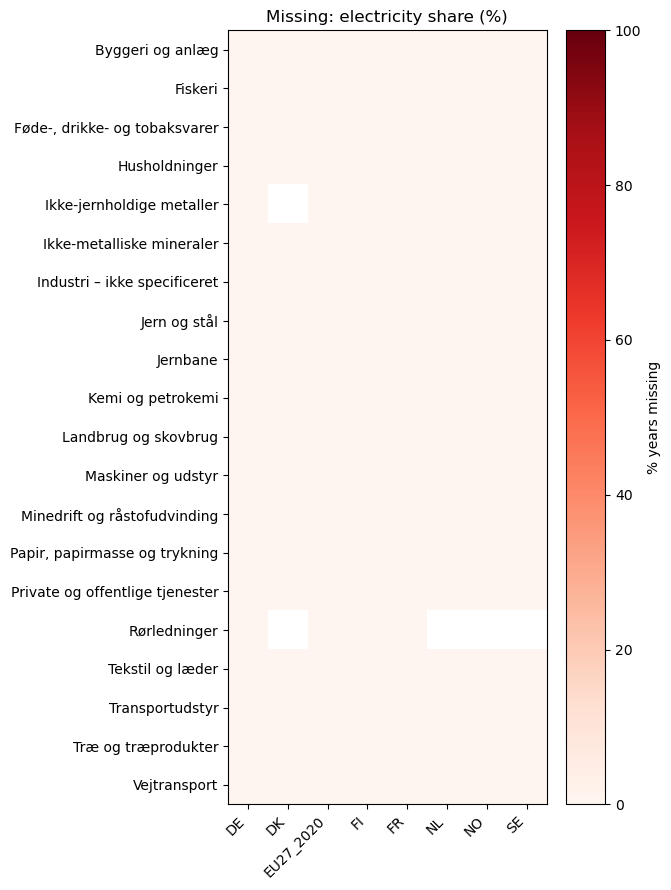

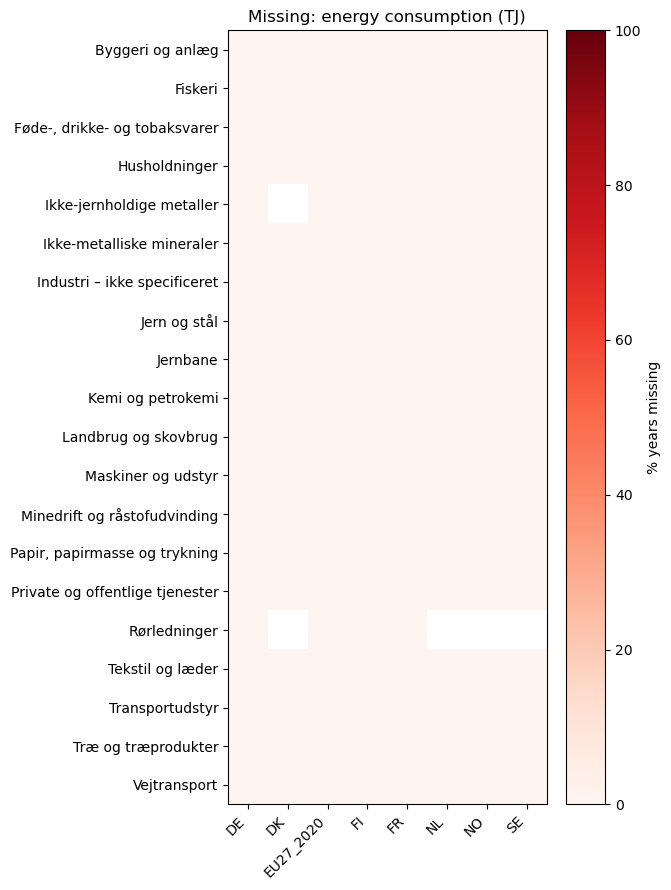

In [16]:
### Missing data: % of years with NaN per (geo × sector)

def missing_heatmap(df, col, title):
    miss = (
        df.groupby(['label', 'geo'])[col]
        .apply(lambda x: x.isna().mean() * 100)
        .unstack('geo')
        .round(1)
    )
    fig, ax = plt.subplots(figsize=(len(miss.columns) * 0.7 + 1, len(miss) * 0.4 + 1))
    im = ax.imshow(miss.values, aspect='auto', cmap='Reds', vmin=0, vmax=100)
    ax.set_xticks(range(len(miss.columns))); ax.set_xticklabels(miss.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(miss.index)));  ax.set_yticklabels(miss.index)
    plt.colorbar(im, ax=ax, label='% years missing')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

missing_heatmap(df, 'elec_share_pct', 'Missing: electricity share (%)')
missing_heatmap(df, 'energy_tj',      'Missing: energy consumption (TJ)')